## Mục tiêu

Notebook này thực hiện EDA toàn diện cho Vietnamese handwriting Dataset, tập trung vào Text Line Dataset.


In [29]:
# ============================================================
# CẤU HÌNH
# ============================================================

CONFIG = {
    # --- Đường dẫn ---
    "textline_labels": "../Dataset/labels.txt",
    "textline_data_dir": "../Dataset/data/",

    # --- Sampling ---
    "n_sample_images": 5000,          # Number of images to sample for dimension analysis

    # --- Training reference (for resized-width analysis) ---
    "image_height": 64,               # Target height used by VietOCR during training
    "image_min_width": 32,            # VietOCR resize() lower clamp
    "image_max_width": 1400,           # VietOCR resize() upper clamp (current default)
#690 -> 32, 1370 -> 64

    # --- Figure sizes ---
    "fig_size_single": (10, 5),      # Single-axis plots
    "fig_size_double": (14, 5),      # Side-by-side plots
    "fig_size_wide": (16, 5),        # Wide bar charts
    "fig_size_grid": (16, 10),       # Image sample grids
    "fig_size_scatter": (8, 6),      # Scatter plots

    # --- Outlier thresholds ---
    "min_label_length": 2,
    "max_label_length": 200,
    "min_aspect_ratio": 0.5,         # width / height
    "max_aspect_ratio": 50.0,

    # --- Sample grid ---
    "sample_grid_rows": 3,
    "sample_grid_cols": 4,

    # --- Random seed ---
    "seed": 42,
}

In [30]:
# ============================================================
# IMPORTS
# ============================================================

import os
import math
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Đảm bảo tái lập kết quả
random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

# Thiết lập style biểu đồ
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 100,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

print("Đã nạp Imports thành công.")

Đã nạp Imports thành công.


In [31]:
# ============================================================
# HÀM HỖ TRỢ
# ============================================================


def load_labels(labels_path: str) -> pd.DataFrame:
    """
    Load a tab-separated labels file into a DataFrame.

    Expected format per line:  image_path<TAB>transcription

    Parameters
    ----------
    labels_path : str
        Path to the labels.txt file.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns ['image_path', 'transcription'].
    """
    rows = []
    with open(labels_path, "r", encoding="utf-8") as f:
        for line_num, line in enumerate(f, start=1):
            line = line.rstrip("\n").rstrip("\r")
            if not line:
                continue
            parts = line.split("\t", maxsplit=1)
            if len(parts) == 2:
                rows.append({"image_path": parts[0], "transcription": parts[1]})
            else:
                # dòng without a tab -- treat transcription as empty string
                rows.append({"image_path": parts[0], "transcription": ""})
    df = pd.DataFrame(rows, columns=["image_path", "transcription"])
    return df


def _resolve_image_path(image_path: str, data_dir: str) -> str:
    """Resolve the full filesystem path for an image.

    The labels file stores paths like 'data/filename.ext', but data_dir
    already points to the 'data/' directory. Strip the 'data/' prefix
    to avoid a double 'data/data/' path.
    """
    rel = image_path
    if rel.startswith("data/"):
        rel = rel[len("data/"):]
    return os.path.join(data_dir, rel)


def plot_distributions(
    data_dict: dict,
    title: str,
    xlabel: str,
    ylabel: str = "Count",
    bins: int = 50,
    figsize: tuple = None,
    alpha: float = 0.55,
):
    """
    Plot overlapping histograms for multiple data series.

    Parameters
    ----------
    data_dict : dict
        Mapping {label_name: array_of_values}.
    title, xlabel, ylabel : str
        Plot labels.
    bins : int
        Number of histogram bins.
    figsize : tuple or None
        Figure size; defaults to CONFIG["fig_size_single"].
    alpha : float
        Histogram transparency.
    """
    if figsize is None:
        figsize = CONFIG["fig_size_single"]
    fig, ax = plt.subplots(figsize=figsize)
    for label, values in data_dict.items():
        ax.hist(values, bins=bins, alpha=alpha, label=label, edgecolor="black", linewidth=0.3)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    plt.tight_layout()
    plt.show()


def show_samples(
    df: pd.DataFrame,
    data_dir: str,
    title: str,
    n_rows: int = None,
    n_cols: int = None,
    figsize: tuple = None,
):
    """
    Display a grid of sample images with their transcriptions as titles.

    Parameters
    ----------
    df : pd.DataFrame
        Must have columns ['image_path', 'transcription'].
    data_dir : str
        Root directory where images are stored.
    title : str
        Super-title for the figure.
    n_rows, n_cols : int or None
        Grid dimensions. Defaults from CONFIG.
    figsize : tuple or None
        Figure size. Defaults from CONFIG.
    """
    if n_rows is None:
        n_rows = CONFIG["sample_grid_rows"]
    if n_cols is None:
        n_cols = CONFIG["sample_grid_cols"]
    if figsize is None:
        figsize = CONFIG["fig_size_grid"]

    n_total = n_rows * n_cols
    sampled = df.sample(n=min(n_total, len(df)), random_state=CONFIG["seed"])

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    fig.suptitle(title, fontsize=15, fontweight="bold")
    axes_flat = axes.flatten()

    for idx, (_, row) in enumerate(sampled.iterrows()):
        if idx >= len(axes_flat):
            break
        ax = axes_flat[idx]
        img_path = _resolve_image_path(row["image_path"], data_dir)
        try:
            img = Image.open(img_path).convert("RGB")
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, f"Error:\n{e}", ha="center", va="center", fontsize=8, transform=ax.transAxes)
        # Truncate long transcriptions for the title
        label_text = row["transcription"]
        if len(label_text) > 60:
            label_text = label_text[:57] + "..."
        ax.set_title(label_text, fontsize=8, pad=3)
        ax.axis("off")

    # Turn off any unused axes
    for idx in range(len(sampled), len(axes_flat)):
        axes_flat[idx].axis("off")

    plt.tight_layout()
    plt.show()


def get_image_dimensions(df: pd.DataFrame, data_dir: str, n_sample: int) -> pd.DataFrame:
    """
    Sample n images and return a DataFrame with width and height.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain column 'image_path'.
    data_dir : str
        Root directory for images.
    n_sample : int
        Number of images to sample.

    Returns
    -------
    pd.DataFrame
        Columns: ['image_path', 'width', 'height'].
    """
    sampled = df.sample(n=min(n_sample, len(df)), random_state=CONFIG["seed"])
    records = []
    for _, row in sampled.iterrows():
        img_path = _resolve_image_path(row["image_path"], data_dir)
        try:
            with Image.open(img_path) as img:
                w, h = img.size
            records.append({"image_path": row["image_path"], "width": w, "height": h})
        except Exception:
            continue
    return pd.DataFrame(records)


def compute_resized_width(w: int, h: int, expected_height: int = CONFIG['image_height']) -> int:
    """Compute the resized width after scaling to expected_height, preserving aspect ratio.

    Mirrors VietOCR's resize() logic WITHOUT clamping, so we can analyze
    the natural width distribution before any information loss.

    Parameters
    ----------
    w : int
        Original image width.
    h : int
        Original image height.
    expected_height : int
        Target height (default 64, matching training CONFIG).

    Returns
    -------
    int
        Resized width, rounded up to nearest 10px (VietOCR convention).
    """
    new_w = int(expected_height * float(w) / float(h))
    round_to = 10
    new_w = math.ceil(new_w / round_to) * round_to
    return max(new_w, 10)  # floor at 10 to avoid degenerate values


def print_dim_stats(dims_df: pd.DataFrame, dataset_name: str):
    """Print min / max / mean / std for width and height."""
    print(f"\n--- {dataset_name} Thống kê kích thước ảnh (n={len(dims_df)}) ---")
    if len(dims_df) == 0:
        print("  Không đo được ảnh nào thành công. Hãy kiểm tra đường dẫn dữ liệu.")
        return
    for col in ["width", "height"]:
        vals = dims_df[col]
        print(
            f"  {col:>6s}:  min={vals.min():6.0f}  max={vals.max():6.0f}  "
            f"mean={vals.mean():7.1f}  std={vals.std():7.1f}"
        )


print("Đã định nghĩa xong các helper functions.")

Đã định nghĩa xong các helper functions.


## 1. Tải và thống kê nhãn


In [32]:
# Tải nhãn
df_textline = load_labels(CONFIG["textline_labels"])

print(f"Text Line dataset : {len(df_textline):,} entries")

print("\n=== Text Line -- First 5 Rows ===")
display(df_textline.head())

Text Line dataset : 16,363 entries

=== Text Line -- First 5 Rows ===


,image_path,transcription
0,data/vn_handwritten_images__1.jpg,"Số 3 Nguyễn Ngọc Vũ, Hà Nội"
1,data/vn_handwritten_images__2.jpg,"Số 30 Nguyên Hồng, Láng Hạ, Đống Đa, Hà Nội"
2,data/vn_handwritten_images__3.jpg,"58 Thái Thịnh, Đống Đa, Hà Nội"
3,data/vn_handwritten_images__4.jpeg,"Số 370/8 khu phố 5B, phường Tân Biên, Biên Hòa..."
4,data/vn_handwritten_images__5.jpg,"Vĩnh Trung Plaza, B, 255-257 đường Hùng Vương,..."


In [33]:
# Count image files in the data directory
data_dir = Path(CONFIG["textline_data_dir"])
img_exts = {".jpg", ".jpeg", ".png"}
image_files = [p for p in data_dir.rglob("*") if p.is_file() and p.suffix.lower() in img_exts]
print(f"Số lượng ảnh trong '{data_dir}': {len(image_files):,}")

Số lượng ảnh trong '../Dataset/data': 16,363


## 2. Phân phối nguồn dữ liệu (Text Line)


Phân phối nguồn dữ liệu (Text Line):
source
VNOnDB_line              7296
UIT_HWDB_line_flat       7229
vn_handwritten_images    1838

Total: 16,363


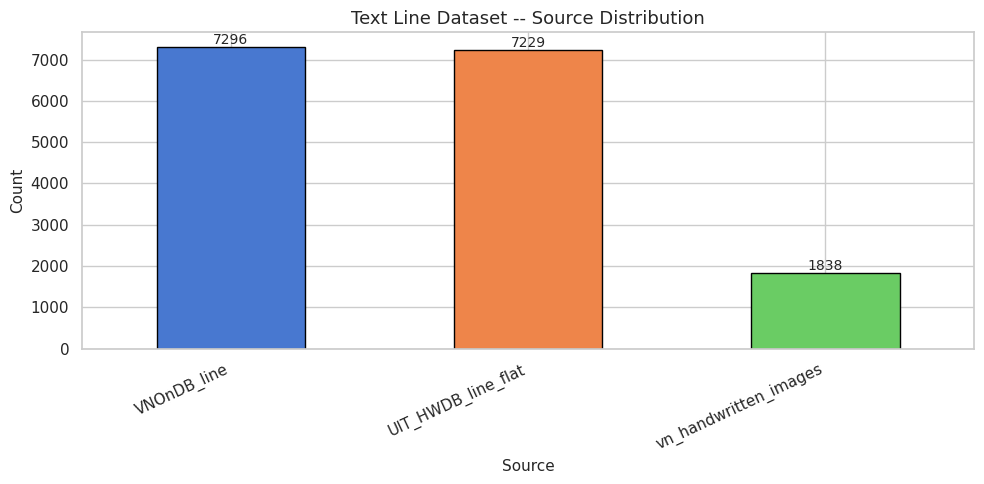

In [34]:
# Extract source prefix (everything before the first '__')
# Use os.đường dẫn.basename to strip the 'data/' directory prefix first
df_textline["source"] = df_textline["image_path"].apply(
    lambda x: os.path.basename(x).split("__")[0] if "__" in x else "unknown"
)

source_counts = df_textline["source"].value_counts()
print("Phân phối nguồn dữ liệu (Text Line):")
print(source_counts.to_string())
print(f"\nTotal: {source_counts.sum():,}")

# Biểu đồ cột
fig, ax = plt.subplots(figsize=CONFIG["fig_size_single"])
source_counts.plot.bar(ax=ax, color=sns.color_palette("muted", n_colors=len(source_counts)), edgecolor="black")
ax.set_title("Text Line Dataset -- Source Distribution")
ax.set_xlabel("Source")
ax.set_ylabel("Count")
ax.bar_label(ax.containers[0], fontsize=10)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 3. Phân tích kích thước ảnh


In [35]:
n_sample = CONFIG["n_sample_images"]

print(f"Sampling up to {n_sample} images from each dataset for dimension analysis...")

dims_textline = get_image_dimensions(df_textline, CONFIG["textline_data_dir"], n_sample)

print(f"  Text Line: {len(dims_textline)} images measured")

# --- Statistics ---
print_dim_stats(dims_textline, "Text Line")

Sampling up to 5000 images from each dataset for dimension analysis...
  Text Line: 5000 images measured

--- Text Line Thống kê kích thước ảnh (n=5000) ---
   width:  min=   382  max=  2606  mean= 1403.7  std=  682.9
  height:  min=    19  max=  2290  mean=  116.0  std=  121.8


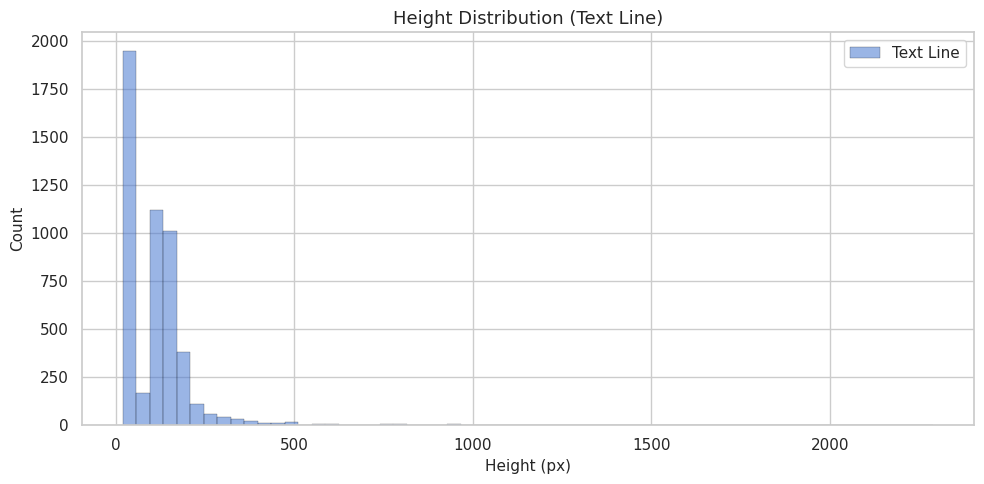

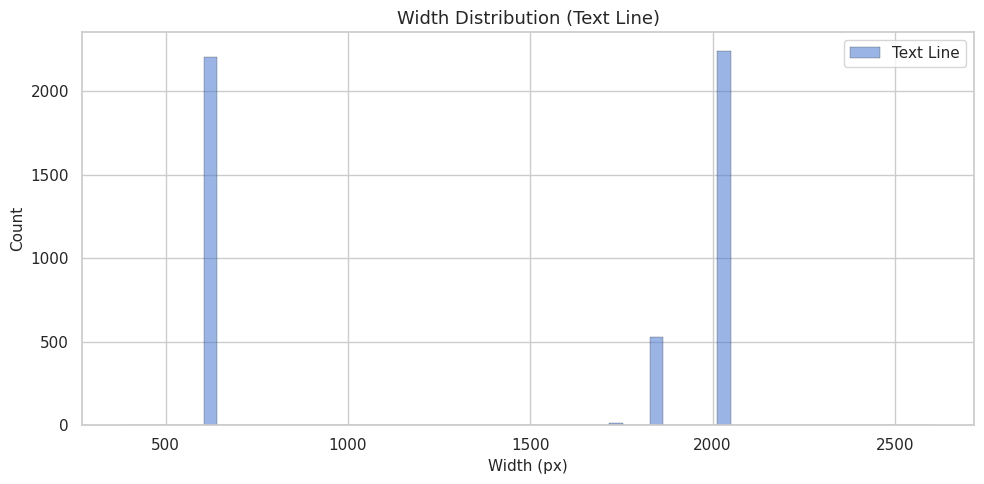

In [36]:
# --- Height phân phối ---
if len(dims_textline) > 0:
    plot_distributions(
        {"Text Line": dims_textline["height"].values},
        title="Height Distribution (Text Line)",
        xlabel="Height (px)",
        bins=60,
    )

    # --- Width phân phối ---
    plot_distributions(
        {"Text Line": dims_textline["width"].values},
        title="Width Distribution (Text Line)",
        xlabel="Width (px)",
        bins=60,
    )
else:
    print("Bỏ qua biểu đồ phân phối kích thước — chưa đo được ảnh nào.")

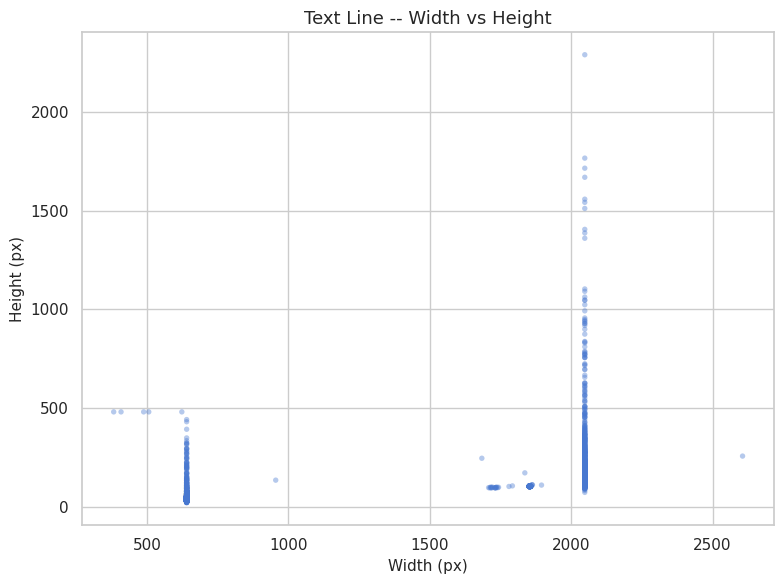

In [37]:
# --- Scatter: Width vs Height ---
if len(dims_textline) > 0:
    fig, ax = plt.subplots(figsize=CONFIG["fig_size_scatter"])
    ax.scatter(dims_textline["width"], dims_textline["height"], alpha=0.4, s=15, edgecolors="none")
    ax.set_title("Text Line -- Width vs Height")
    ax.set_xlabel("Width (px)")
    ax.set_ylabel("Height (px)")
    plt.tight_layout()
    plt.show()
else:
    print("Bỏ qua scatter plot — chưa đo được ảnh nào.")

In [38]:
# Compute and display the 95th percentile of image heights (safe if dims_textline is empty)
if "dims_textline" in globals() and len(dims_textline) > 0:
  p95_height = np.percentile(dims_textline["height"], 95)
  print(f"95th percentile (p95) of image heights: {p95_height:.0f} px")
else:
  print("Không có dữ liệu chiều cao (dims_textline rỗng).")

95th percentile (p95) of image heights: 249 px


In [39]:
print("Median height:", np.median(dims_textline["height"]))
print("Mean height:", np.mean(dims_textline["height"]))

Median height: 103.0
Mean height: 115.9568


## 3b. Phân tích chiều rộng sau resize

Hàm `resize()` của VietOCR scale ảnh về chiều cao cố định (64px) đồng thời giữ tỉ lệ,
sau đó chặn chiều rộng trong khoảng `[image_min_width, image_max_width]`.

**Chiều rộng sau resize** (không phải chiều rộng gốc) quyết định:
- Độ phân giải không gian của feature map đưa vào encoder
- Mức tiêu thụ bộ nhớ GPU theo batch
- Mức giữ/loss thông tin không gian do cơ chế clamping

Ta tính `resized_w_unclamped` — chiều rộng tự nhiên sau khi resize về height=64,
**trước** khi clamping — để hiểu phân phối chiều rộng thực tế mà
pipeline huấn luyện phải xử lý.

In [40]:
# ============================================================
# 3b-1. Compute resized widths and percentile statistics
# ============================================================

if len(dims_textline) > 0:
    # --- Compute resized width BEFORE clamping ---
    dims_textline["resized_w_unclamped"] = dims_textline.apply(
        lambda row: compute_resized_width(row["width"], row["height"], CONFIG["image_height"]),
        axis=1,
    )

    # --- Compute resized width AFTER current clamp (512) ---
    dims_textline["resized_w_clamped_512"] = dims_textline["resized_w_unclamped"].clip(
        lower=CONFIG["image_min_width"], upper=CONFIG["image_max_width"]
    )

    # --- Percentile table ---
    percentiles = [50, 75, 90, 95, 99]
    pct_values = np.percentile(dims_textline["resized_w_unclamped"], percentiles)
    p_dict = dict(zip(percentiles, pct_values))

    print("=" * 60)
    print("RESIZED WIDTH (UNCLAMPED) — PERCENTILE TABLE")
    print("=" * 60)
    for p, v in p_dict.items():
        print(f"  p{p:02d} = {v:,.0f} px")

    # --- Clamping rate at current default (512) ---
    n_total = len(dims_textline)
    n_clamped_512 = (dims_textline["resized_w_unclamped"] > CONFIG["image_max_width"]).sum()
    pct_clamped_512 = n_clamped_512 / n_total * 100

    print(f"\n--- Clamping at current image_max_width={CONFIG['image_max_width']} ---")
    print(f"  Images clamped : {n_clamped_512:,} / {n_total:,} ({pct_clamped_512:.1f}%)")
    print(f"  Images retained: {n_total - n_clamped_512:,} / {n_total:,} ({100 - pct_clamped_512:.1f}%)")

    # --- Basic stats ---
    rw = dims_textline["resized_w_unclamped"]
    print(f"\n--- Resized width (unclamped) stats ---")
    print(f"  min  = {rw.min():,.0f}")
    print(f"  max  = {rw.max():,.0f}")
    print(f"  mean = {rw.mean():,.1f}")
    print(f"  std  = {rw.std():,.1f}")
else:
    print("Bỏ qua — chưa đo được ảnh nào.")

RESIZED WIDTH (UNCLAMPED) — PERCENTILE TABLE
  p50 = 980 px
  p75 = 1,160 px
  p90 = 1,250 px
  p95 = 1,370 px
  p99 = 1,580 px

--- Clamping at current image_max_width=1400 ---
  Images clamped : 202 / 5,000 (4.0%)
  Images retained: 4,798 / 5,000 (96.0%)

--- Resized width (unclamped) stats ---
  min  = 50
  max  = 2,160
  mean = 961.7
  std  = 275.0


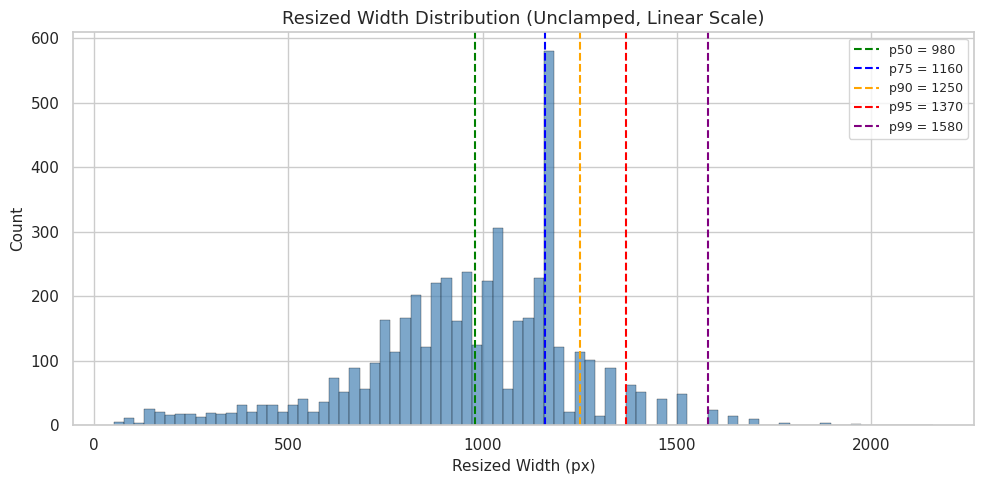

In [41]:
# ============================================================
# 3b-2. Histogram of resized_w_unclamped (linear scale)
# ============================================================

if len(dims_textline) > 0 and "resized_w_unclamped" in dims_textline.columns:
    rw = dims_textline["resized_w_unclamped"]
    percentiles = [50, 75, 90, 95, 99]
    pct_values = np.percentile(rw, percentiles)
    colors_pct = ["green", "blue", "orange", "red", "purple"]

    fig, ax = plt.subplots(figsize=CONFIG["fig_size_single"])
    ax.hist(rw, bins=80, alpha=0.7, edgecolor="black", linewidth=0.3, color="steelblue")
    for p, v, c in zip(percentiles, pct_values, colors_pct):
        ax.axvline(v, color=c, linestyle="--", linewidth=1.5, label=f"p{p} = {v:.0f}")
    ax.set_title("Resized Width Distribution (Unclamped, Linear Scale)")
    ax.set_xlabel("Resized Width (px)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

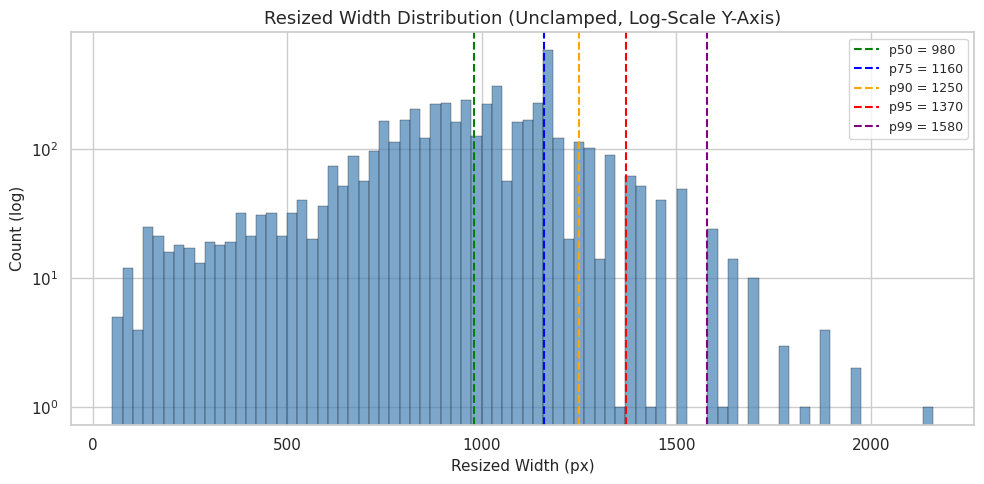

In [42]:
# ============================================================
# 3b-3. Histogram of resized_w_unclamped (log-scale y-axis)
# ============================================================

if len(dims_textline) > 0 and "resized_w_unclamped" in dims_textline.columns:
    rw = dims_textline["resized_w_unclamped"]
    percentiles = [50, 75, 90, 95, 99]
    pct_values = np.percentile(rw, percentiles)
    colors_pct = ["green", "blue", "orange", "red", "purple"]

    fig, ax = plt.subplots(figsize=CONFIG["fig_size_single"])
    ax.hist(rw, bins=80, alpha=0.7, edgecolor="black", linewidth=0.3, color="steelblue")
    for p, v, c in zip(percentiles, pct_values, colors_pct):
        ax.axvline(v, color=c, linestyle="--", linewidth=1.5, label=f"p{p} = {v:.0f}")
    ax.set_yscale("log")
    ax.set_title("Resized Width Distribution (Unclamped, Log-Scale Y-Axis)")
    ax.set_xlabel("Resized Width (px)")
    ax.set_ylabel("Count (log)")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

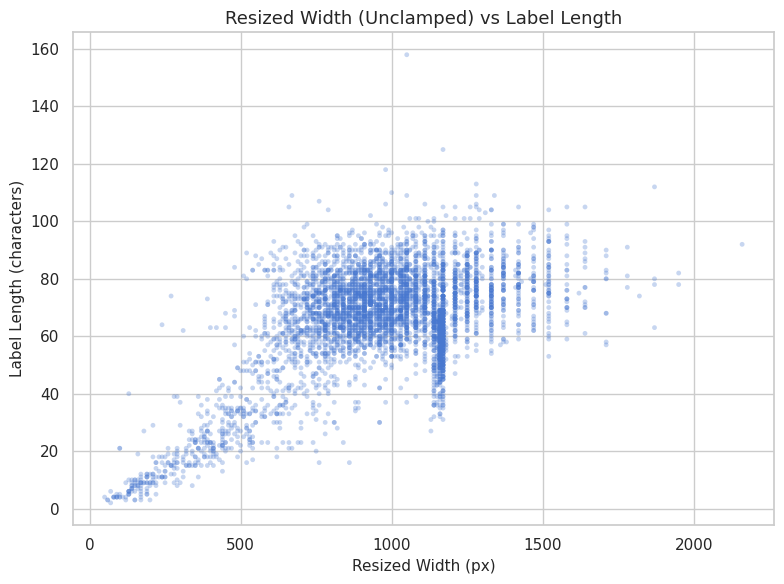

In [43]:
# ============================================================
# 3b-4. Scatter: resized_w_unclamped vs label_length
# ============================================================

if len(dims_textline) > 0 and "resized_w_unclamped" in dims_textline.columns:
    # Ensure label_len exists on df_textline
    if "label_len" not in df_textline.columns:
        df_textline["label_len"] = df_textline["transcription"].str.len()

    # Merge resized width with label length via image_path
    dims_with_len = dims_textline.merge(
        df_textline[["image_path", "label_len"]],
        on="image_path",
        how="inner",
    )

    if len(dims_with_len) > 0:
        fig, ax = plt.subplots(figsize=CONFIG["fig_size_scatter"])
        ax.scatter(
            dims_with_len["resized_w_unclamped"],
            dims_with_len["label_len"],
            alpha=0.3, s=12, edgecolors="none",
        )
        ax.set_title("Resized Width (Unclamped) vs Label Length")
        ax.set_xlabel("Resized Width (px)")
        ax.set_ylabel("Label Length (characters)")
        plt.tight_layout()
        plt.show()
    else:
        print("Không merge được dims_textline với label_len.")

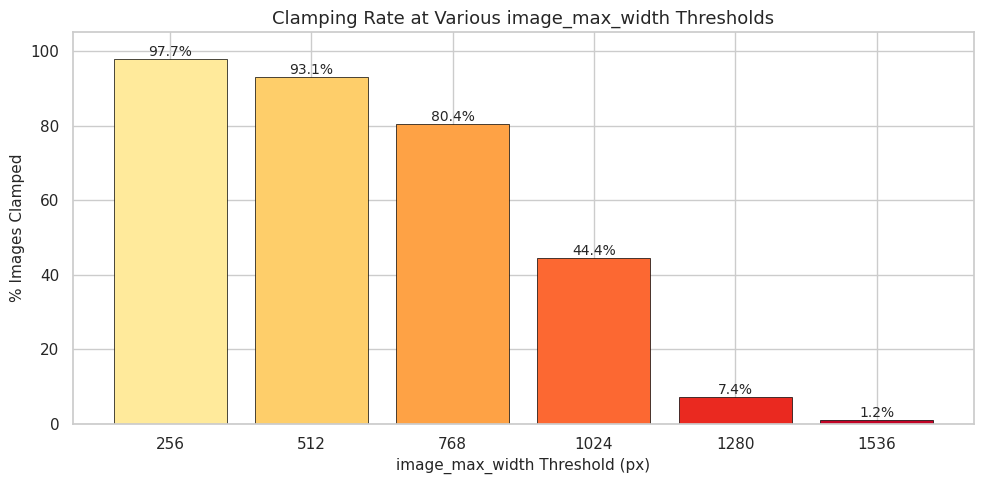


Clamp rate summary:
  image_max_width=  256  =>   97.7% clamped
  image_max_width=  512  =>   93.1% clamped
  image_max_width=  768  =>   80.4% clamped
  image_max_width= 1024  =>   44.4% clamped
  image_max_width= 1280  =>    7.4% clamped
  image_max_width= 1536  =>    1.2% clamped


In [44]:
# ============================================================
# 3b-5. Bar chart: clamp rate at various image_max_width thresholds
# ============================================================

if len(dims_textline) > 0 and "resized_w_unclamped" in dims_textline.columns:
    rw = dims_textline["resized_w_unclamped"]
    thresholds = [256, 512, 768, 1024, 1280, 1536]
    clamp_rates = []
    for t in thresholds:
        pct = (rw > t).sum() / len(rw) * 100
        clamp_rates.append(pct)

    fig, ax = plt.subplots(figsize=CONFIG["fig_size_single"])
    bars = ax.bar(
        [str(t) for t in thresholds], clamp_rates,
        color=sns.color_palette("YlOrRd", len(thresholds)),
        edgecolor="black", linewidth=0.5,
    )
    ax.bar_label(bars, fmt="%.1f%%", fontsize=10)
    ax.set_title("Clamping Rate at Various image_max_width Thresholds")
    ax.set_xlabel("image_max_width Threshold (px)")
    ax.set_ylabel("% Images Clamped")
    ax.set_ylim(0, 105)
    plt.tight_layout()
    plt.show()

    # Print table
    print("\nClamp rate summary:")
    for t, r in zip(thresholds, clamp_rates):
        print(f"  image_max_width={t:>5d}  =>  {r:5.1f}% clamped")

Long-tail detection (resized_w_unclamped > p99 = 1580 px)
  Count: 36 images

  Showing up to 12 samples:
                                        image_path  width  height  resized_w_unclamped
data/VNOnDB_line__20160426_0106_25600_1_tg_6_0.png    640      24                 1710
 data/VNOnDB_line__20160510_0121_9129_1_tg_2_1.png    640      25                 1640
  data/VNOnDB_line__20160123_0079_25344_tg_1_1.png    640      22                 1870
  data/VNOnDB_line__20160123_0079_25344_tg_0_6.png    640      24                 1710
 data/VNOnDB_line__20160412_0091_9539_1_tg_0_2.png    640      25                 1640
  data/VNOnDB_line__20160604_0197_25272_tg_0_2.png    640      24                 1710
data/VNOnDB_line__20160722_0200_28472_1_tg_3_1.png    640      25                 1640
  data/VNOnDB_line__20140603_0017_BCCTC_tg_3_1.png    640      24                 1710
 data/VNOnDB_line__20160512_0129_9244_1_tg_3_1.png    640      25                 1640
  data/VNOnDB_line__2016

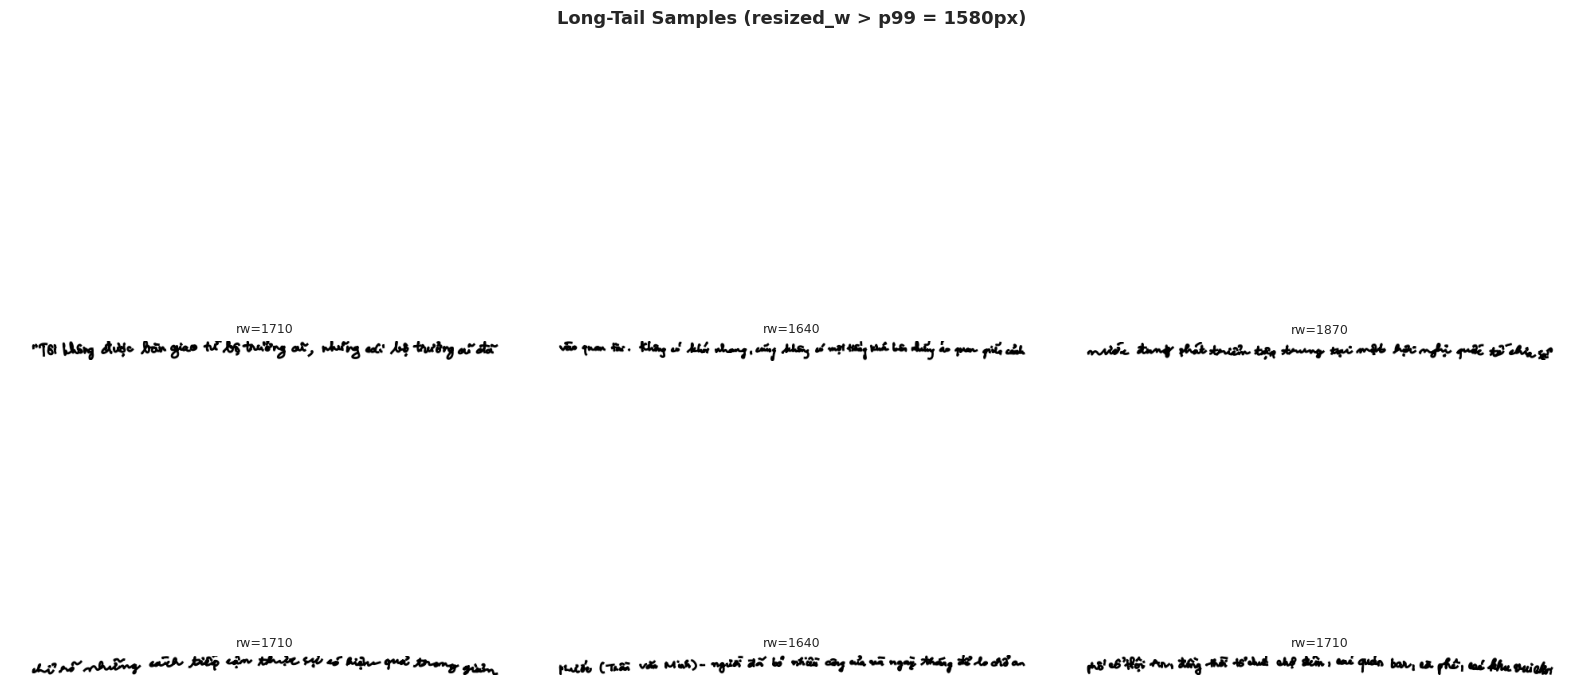

In [45]:
# ============================================================
# 3b-6. Long-tail detection: images with resized_w_unclamped > p99
# ============================================================

if len(dims_textline) > 0 and "resized_w_unclamped" in dims_textline.columns:
    rw = dims_textline["resized_w_unclamped"]
    p99_val = np.percentile(rw, 99)

    longtail_mask = rw > p99_val
    n_longtail = longtail_mask.sum()

    print(f"Long-tail detection (resized_w_unclamped > p99 = {p99_val:.0f} px)")
    print(f"  Count: {n_longtail} images")

    if n_longtail > 0:
        longtail_samples = dims_textline[longtail_mask].head(12)
        print(f"\n  Showing up to {len(longtail_samples)} samples:")
        print(longtail_samples[["image_path", "width", "height", "resized_w_unclamped"]].to_string(index=False))

        # Show a few sample images
        n_show = min(6, len(longtail_samples))
        if n_show > 0:
            fig, axes = plt.subplots(2, 3, figsize=CONFIG["fig_size_grid"])
            fig.suptitle(f"Long-Tail Samples (resized_w > p99 = {p99_val:.0f}px)", fontsize=13, fontweight="bold")
            axes_flat = axes.flatten()
            for idx, (_, row) in enumerate(longtail_samples.head(n_show).iterrows()):
                ax = axes_flat[idx]
                img_path = _resolve_image_path(row["image_path"], CONFIG["textline_data_dir"])
                try:
                    img = Image.open(img_path).convert("RGB")
                    ax.imshow(img)
                    ax.set_title(f"rw={row['resized_w_unclamped']:.0f}", fontsize=9)
                except Exception:
                    ax.text(0.5, 0.5, "Error", ha="center", va="center", transform=ax.transAxes)
                ax.axis("off")
            for idx in range(n_show, len(axes_flat)):
                axes_flat[idx].axis("off")
            plt.tight_layout()
            plt.show()

### Tóm tắt phân tích chiều rộng sau resize

**Kết luận chính:**

- `resized_w_unclamped` = chiều rộng sau khi resize về height=64 và giữ tỉ lệ, TRƯỚC khi clamping.
- **`image_max_width` khuyến nghị** = **p95 của `resized_w_unclamped`** (xem bảng percentile ở trên).
    - Cách này giữ được thông tin không gian cho ~95% ảnh.
    - ~5% ảnh ở đuôi dài (vượt p95) sẽ bị clamping — đây là đánh đổi hợp lý giữa giữ thông tin và kiểm soát tài nguyên.
- **Tỷ lệ clamping kỳ vọng** tại p95: ~5%.
- **Ảnh hưởng bộ nhớ**: tăng `image_max_width` từ 512 lên p95 sẽ tăng peak GPU memory gần tuyến tính (`memory ~ batch_size x image_height x width`). Có thể cần giảm `batch_size` (ví dụ 32 -> 16).
- **Nếu giữ mặc định 512**: tỷ lệ ảnh bị clamping rất cao (xem phần trên), gây mất thông tin đáng kể và làm giảm hiệu quả gom cụm theo chiều rộng của VietOCR.
- `ClusterRandomSampler` của VietOCR nhóm ảnh theo chiều rộng sau resize. Khi đa số ảnh cùng bị kẹp về 512, cơ chế gom cụm gần như suy biến.

## 4. Phân phối độ dài nhãn


In [46]:
# Tính label lengths
df_textline["label_len"] = df_textline["transcription"].str.len()

# --- Statistics ---
for name, df in [("Text Line", df_textline)]:
    lens = df["label_len"]
    print(f"\n--- {name} Thống kê độ dài nhãn ---")
    print(f"  min    = {lens.min()}")
    print(f"  max    = {lens.max()}")
    print(f"  mean   = {lens.mean():.2f}")
    print(f"  median = {lens.median():.1f}")
    print(f"  std    = {lens.std():.2f}")


--- Text Line Thống kê độ dài nhãn ---
  min    = 2
  max    = 158
  mean   = 66.42
  median = 69.0
  std    = 18.03


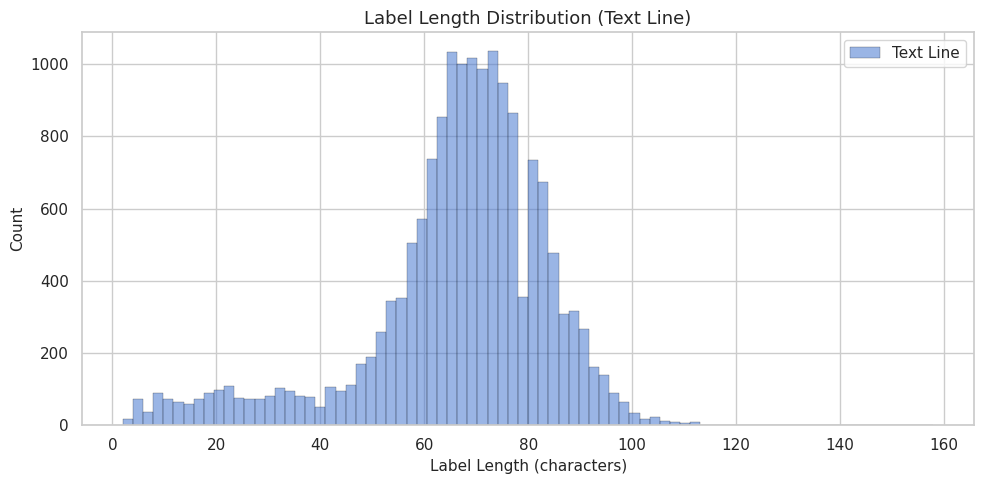

In [47]:
# --- Overlapping histogram ---
plot_distributions(
    {"Text Line": df_textline["label_len"].values},
    title="Label Length Distribution (Text Line)",
    xlabel="Label Length (characters)",
    bins=80,
)

/tmp/ipykernel_133315/2389975726.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


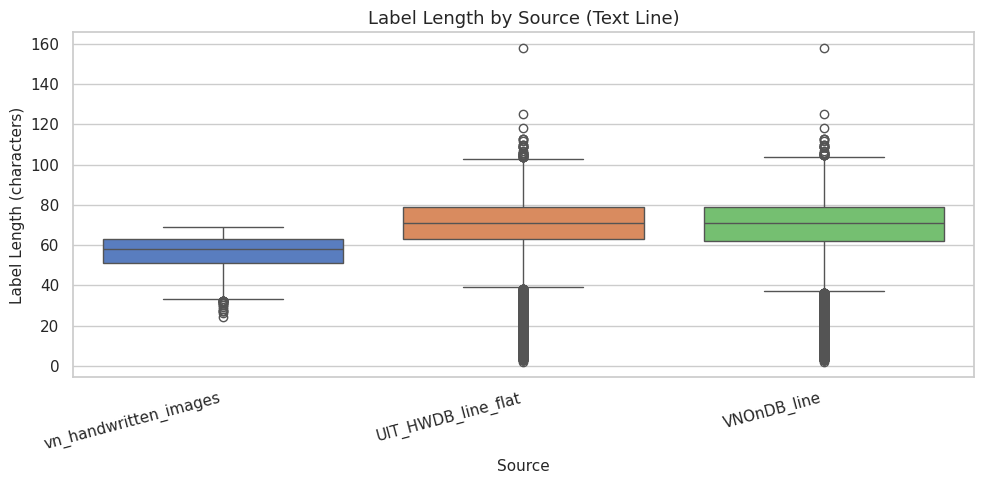

In [48]:
# --- Box biểu đồ by source (Text Line only) ---
fig, ax = plt.subplots(figsize=CONFIG["fig_size_single"])
sns.boxplot(
    data=df_textline,
    x="source",
    y="label_len",
    ax=ax,
    palette="muted",
)
ax.set_title("Label Length by Source (Text Line)")
ax.set_xlabel("Source")
ax.set_ylabel("Label Length (characters)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 5. Tần suất ký tự & phân tích charset


In [49]:
def build_char_counter(df: pd.DataFrame) -> Counter:
    """Count every character across all transcriptions."""
    counter = Counter()
    for text in df["transcription"]:
        counter.update(text)
    return counter


counter_textline = build_char_counter(df_textline)

charset_textline = set(counter_textline.keys())

print(f"Số ký tự duy nhất -- Text Line : {len(charset_textline)}")


Số ký tự duy nhất -- Text Line : 168


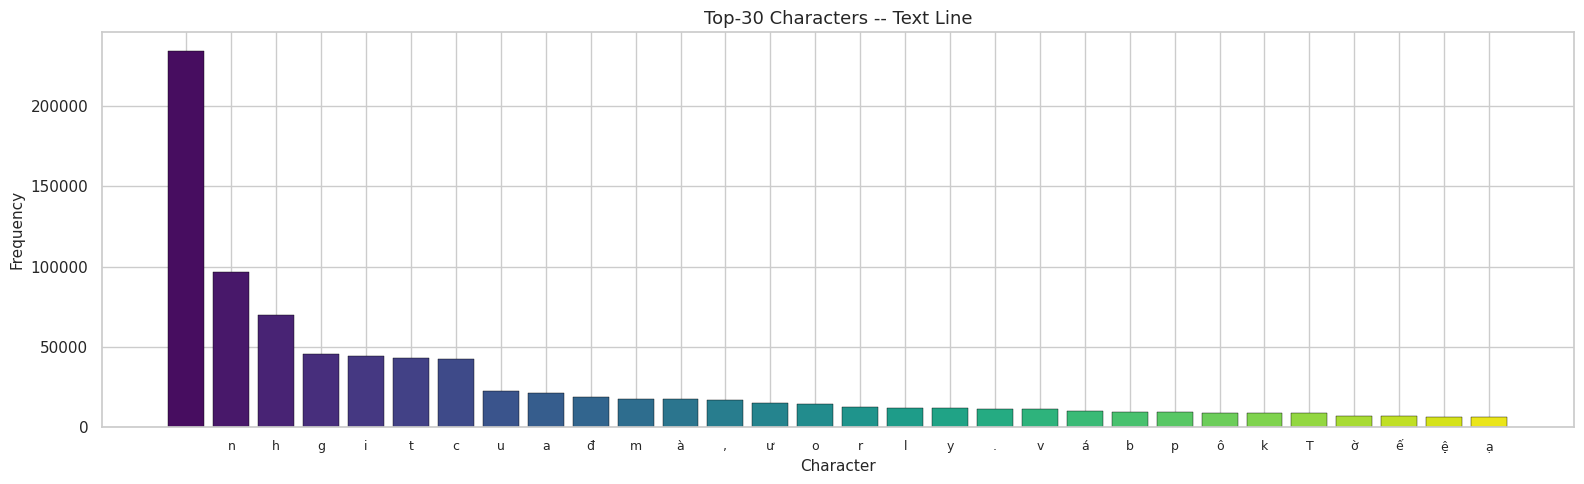

In [50]:
# --- Top-30 ký tự bar chart (Text Line) ---
top_n = 30

most_common = counter_textline.most_common(top_n)
chars = [repr(c)[1:-1] if c == " " else c for c, _ in most_common]  # show space visibly
counts = [cnt for _, cnt in most_common]

fig, ax = plt.subplots(figsize=CONFIG["fig_size_wide"])
ax.bar(range(len(chars)), counts, color=sns.color_palette("viridis", top_n), edgecolor="black", linewidth=0.3)
ax.set_xticks(range(len(chars)))
ax.set_xticklabels(chars, fontsize=9)
ax.set_title(f"Top-{top_n} Characters -- Text Line")
ax.set_xlabel("Character")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [51]:
# --- Full charset (sorted) ---
print("=== Full Charset -- Text Line (sorted) ===")
sorted_charset_tl = sorted(charset_textline)
print("".join(sorted_charset_tl))
print(f"\nTotal: {len(sorted_charset_tl)} characters\n")

=== Full Charset -- Text Line (sorted) ===
 !"#%&'()*+,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYabcdefghijklmnopqrstuvwxyzÀÁÂÊÔÚÝàáâãèéêìíòóôõùúýĂăĐđĩũƠơƯưạẢảẤấẦầẩẫậắằẳẵặẹẻẽếỀềỂểễỆệỉịọỏỐốỒồổỗộớờỞởỡợụỦủỨứừửữựỳỵỷỹ

Total: 168 characters



In [52]:
# --- Flag non-Vietnamese / unexpected ký tự ---
VIETNAMESE_LOWER = set("aăâbcdđeêghiklmnoôơpqrstuưvxy")
VIETNAMESE_UPPER = set(c.upper() for c in VIETNAMESE_LOWER)
VIETNAMESE_TONED = set(
    "àáảãạằắẳẵặầấẩẫậèéẻẽẹềếểễệìíỉĩịòóỏõọồốổỗộờớởỡợùúủũụừứửữựỳýỷỹỵ"
    "ÀÁẢÃẠẰẮẲẴẶẦẤẨẪẬÈÉẺẼẸỀẾỂỄỆÌÍỈĨỊÒÓỎÕỌỒỐỔỖỘỜỚỞỠỢÙÚỦŨỤỪỨỬỮỰỲÝỶỸỴ"
)
DIGITS = set("0123456789")
PUNCTUATION = set(".,;:!?\'\"()-/\\@#$%&*+=_~^{}[]<>|` ")

EXPECTED_CHARS = VIETNAMESE_LOWER | VIETNAMESE_UPPER | VIETNAMESE_TONED | DIGITS | PUNCTUATION

unexpected = charset_textline - EXPECTED_CHARS

if unexpected:
    print(f"Unexpected / non-Vietnamese characters found ({len(unexpected)}):")
    for ch in sorted(unexpected):
        import unicodedata
        try:
            char_name = unicodedata.name(ch)
        except ValueError:
            char_name = "UNKNOWN"
        print(f"  '{ch}'  U+{ord(ch):04X}  {char_name:40s}  TextLine(n={counter_textline[ch]})")
else:
    print("No unexpected characters found. All characters are within the expected Vietnamese charset.")

Unexpected / non-Vietnamese characters found (7):
  'F'  U+0046  LATIN CAPITAL LETTER F                    TextLine(n=10)
  'J'  U+004A  LATIN CAPITAL LETTER J                    TextLine(n=37)
  'W'  U+0057  LATIN CAPITAL LETTER W                    TextLine(n=33)
  'f'  U+0066  LATIN SMALL LETTER F                      TextLine(n=52)
  'j'  U+006A  LATIN SMALL LETTER J                      TextLine(n=36)
  'w'  U+0077  LATIN SMALL LETTER W                      TextLine(n=1)
  'z'  U+007A  LATIN SMALL LETTER Z                      TextLine(n=10)


## 6. Trực quan hóa mẫu


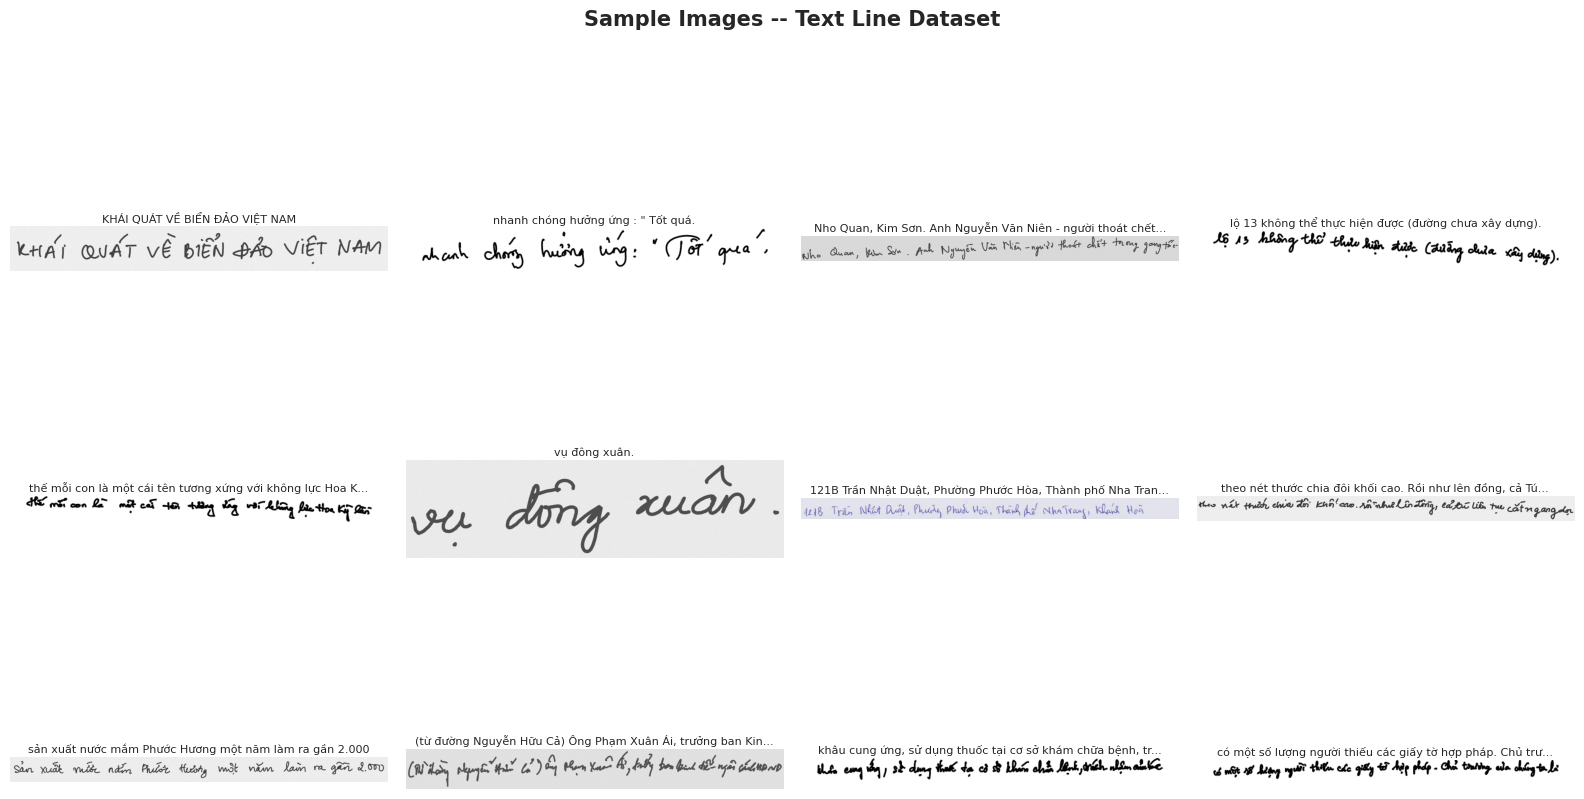

In [53]:
# --- Text Line mẫu ---
show_samples(
    df_textline,
    CONFIG["textline_data_dir"],
    title="Sample Images -- Text Line Dataset",
)

## 7. Phát hiện outlier


In [54]:
# --- 7a. Empty or whitespace-only transcriptions ---
print("=" * 60)
print("TRANSCRIPTION RỖNG HOẶC CHỈ CÓ KHOẢNG TRẮNG")
print("=" * 60)

mask_empty = df_textline["transcription"].str.strip() == ""
n_empty = mask_empty.sum()
print(f"\nText Line: {n_empty} empty/whitespace-only transcription(s)")
if n_empty > 0:
    display(df_textline[mask_empty].head(20))

TRANSCRIPTION RỖNG HOẶC CHỈ CÓ KHOẢNG TRẮNG

Text Line: 0 empty/whitespace-only transcription(s)


In [55]:
# --- 7b. Short and long nhãn ---
min_len = CONFIG["min_label_length"]
max_len = CONFIG["max_label_length"]

print("=" * 60)
print(f"LABELS WITH LENGTH < {min_len} OR > {max_len} CHARACTERS")
print("=" * 60)

mask_short = df_textline["label_len"] < min_len
mask_long  = df_textline["label_len"] > max_len
n_short = mask_short.sum()
n_long  = mask_long.sum()

print(f"\n--- Text Line ---")
print(f"  Short labels (< {min_len} chars): {n_short}")
if n_short > 0:
    display(df_textline[mask_short][["image_path", "transcription", "label_len"]].head(20))

print(f"  Long labels (> {max_len} chars) : {n_long}")
if n_long > 0:
    display(df_textline[mask_long][["image_path", "transcription", "label_len"]].head(20))

LABELS WITH LENGTH < 2 OR > 200 CHARACTERS

--- Text Line ---
  Short labels (< 2 chars): 0
  Long labels (> 200 chars) : 0


In [56]:
# --- 7c. Extreme aspect ratios ---
min_ar = CONFIG["min_aspect_ratio"]
max_ar = CONFIG["max_aspect_ratio"]

print("=" * 60)
print(f"IMAGES WITH ASPECT RATIO (W/H) < {min_ar} OR > {max_ar}")
print("=" * 60)

if len(dims_textline) == 0:
    print("\nKhông có dữ liệu kích thước (đo được 0 ảnh).")
else:
    dims_tl = dims_textline.copy()
    dims_tl["aspect_ratio"] = dims_tl["width"] / dims_tl["height"]

    mask_extreme = (dims_tl["aspect_ratio"] < min_ar) | (dims_tl["aspect_ratio"] > max_ar)
    n_extreme = mask_extreme.sum()

    print(f"\n--- Text Line (sampled {len(dims_tl)} images) ---")
    print(f"  Extreme aspect ratios: {n_extreme}")
    if n_extreme > 0:
        display(
            dims_tl[mask_extreme]
            .sort_values("aspect_ratio", ascending=False)
            .reset_index(drop=True)
        )
    else:
        print("  Không phát hiện trong tập ảnh đã lấy mẫu.")

    ar = dims_tl["aspect_ratio"]
    print(f"  Aspect ratio stats: min={ar.min():.2f}  max={ar.max():.2f}  "
          f"mean={ar.mean():.2f}  std={ar.std():.2f}")

IMAGES WITH ASPECT RATIO (W/H) < 0.5 OR > 50.0

--- Text Line (sampled 5000 images) ---
  Extreme aspect ratios: 0
  Không phát hiện trong tập ảnh đã lấy mẫu.
  Aspect ratio stats: min=0.80  max=33.68  mean=14.97  std=4.29


## 8. Tổng kết


## Tóm tắt kiểm định dữ liệu Phase 1


# Khuyến nghị chuẩn bị dữ liệu cho Phase 1

Dựa trên EDA thực tế trong notebook này:
- **Kích thước dataset**: 16,363 mẫu (Text Line).
- **Phân phối nguồn**: VNOnDB_line 7,296; UIT_HWDB_line_flat 7,229; vn_handwritten_images 1,838.
- **Độ dài nhãn**: min=2, max=158, mean=66.42, median=69.0, std=18.03.
- **Thống kê ảnh (mẫu 5,000 ảnh)**: width min=382, max=2,606, mean=1,403.7; height min=19, max=2,290, mean=116.0.
- **Aspect ratio (W/H)**: min=0.80, max=33.68, mean=14.97; số mẫu cực trị theo ngưỡng (<0.5 hoặc >50) = 0.
- **Charset**: 168 ký tự; ký tự hiếm/không thuộc bộ kỳ vọng: F(10), J(37), W(33), f(52), j(36), w(1), z(10).
- **Nhãn rỗng**: 0; **nhãn quá ngắn (<2)**: 0; **nhãn quá dài (>200)**: 0.

---

## A. Chiến lược làm sạch nhãn

### 1) Xác nhận chuẩn hóa Unicode
- **Khuyến nghị**: bắt buộc chuẩn hóa toàn bộ nhãn về **NFC** trước khi split/train.
- **Lý do**: dữ liệu tiếng Việt có nhiều dấu; cùng ký tự hiển thị có thể có nhiều dạng Unicode (composed/decomposed). Nếu không chuẩn hóa sẽ gây lệch vocabulary và tăng CER/WER giả tạo.
- **Quy tắc**: áp dụng `unicodedata.normalize('NFC', text)` cho mọi transcription.

### 2) Có loại bỏ nhãn cực ngắn không?
- **Quyết định**: **không loại thêm theo ngưỡng <2**, vì EDA cho thấy hiện tại đã **0 mẫu**.
- **Lý do**: không có lợi ích lọc thêm ở ngưỡng này.
- **Quy tắc an toàn**: vẫn giữ kiểm tra runtime `len(strip_text) >= 2` để chặn dữ liệu lỗi mới phát sinh.

### 3) Có loại bỏ nhãn quá dài không?
- **Quyết định**: **không cần loại theo ngưỡng >200** ở tập hiện tại vì EDA ghi nhận **0 mẫu**.
- **Khuyến nghị bổ sung cho Baseline**: đặt ngưỡng huấn luyện thực tế `max_label_len = 180` hoặc theo `p99` (nếu tính được) để ổn định Batch memory, nhưng không cần xóa dữ liệu hiện có.
- **Lý do**: max hiện tại chỉ 158 nên an toàn.

### 4) Có lọc ký tự hiếm/không kỳ vọng không?
- **Quyết định**: **không loại các ký tự hiếm F/J/W/f/j/w/z**.
- **Lý do**: tần suất thấp nhưng là ký tự hợp lệ trong từ mượn/tên riêng; xóa sẽ làm sai ground-truth và giảm khả năng tổng quát hóa.
- **Quy tắc**:
  - Giữ nguyên ký tự có trong dữ liệu huấn luyện.
  - Chỉ loại ký tự điều khiển/không in được (`Cc`, `Cf`) nếu xuất hiện.
  - Chuẩn hóa khoảng trắng: co cụm nhiều khoảng trắng về 1 khoảng trắng và `strip()` hai đầu.

---

## B. Chiến lược xử lý ảnh

### 1) Chính sách resize
- **Quyết định**: dùng **keep aspect ratio**, cố định **height** (khuyến nghị `imgH=64` cho Phase 1 Baseline), không ép fixed width.
- **Lý do theo EDA**:
  - Width biến thiên lớn (382–2,606; std cao 682.9).
  - Height trung bình thấp (~116) nhưng trải rộng (19–2,290).
  - Ép fixed width dễ méo chữ và làm mất thông tin hình dạng ký tự.

### 2) Phương pháp padding
- **Quyết định**: resize theo height rồi **right-padding** đến `max_width` của batch/model.
- **Khuyến nghị**:
  - Padding value theo nền sáng (255) hoặc theo mean background của ảnh sau resize.
  - Có thể dùng bucket theo chiều rộng để giảm lãng phí padding.
- **Lý do**: aspect ratio trung bình ~14.97 cho thấy text line dài; padding bên phải phù hợp với cấu trúc dòng chữ.

### 3) Chuyển grayscale
- **Quyết định**: **khuyến nghị chuyển grayscale** cho Baseline.
- **Lý do**: OCR chữ viết tay chủ yếu phụ thuộc cấu trúc nét; giảm chiều kênh giúp train ổn định và tiết kiệm compute.
- **Lưu ý**: giữ tùy chọn RGB nếu cần thử nghiệm sau Baseline.

### 4) Chuẩn hóa ảnh
- **Quyết định**: scale pixel về [0,1] và chuẩn hóa bằng mean/std của tập train (hoặc mean=0.5, std=0.5 cho Baseline).
- **Lý do**: giúp tối ưu ổn định, nhất quán giữa train/validation/test.

---

## C. Quy tắc lọc dữ liệu (Phase 1)

### Rule 1 — Tính hợp lệ nhãn
- Loại mẫu nếu transcription rỗng sau `strip()`.
- Ngưỡng: `len(text) < 2` => loại (hiện trạng: 0 mẫu).

### Rule 2 — Ràng buộc độ dài
- Không loại theo >200 ở dữ liệu hiện tại (0 mẫu).
- Dùng ngưỡng bảo vệ trong dataloader: `len(text) <= 180` (hoặc theo `p99`) để tránh sample bất thường mới.

### Rule 3 — Ràng buộc charset
- Không loại ký tự hiếm hợp lệ (F/J/W/f/j/w/z).
- Loại ký tự control/non-printable nếu phát hiện.
- Vocabulary dùng mặc định VietOCR, không ghi đè thủ công.

### Rule 4 — Tính toàn vẹn ảnh
- Loại ảnh lỗi đọc/ảnh hỏng.
- Loại ảnh quá nhỏ (ví dụ min dimension <16 px).
- Tiếp tục theo dõi aspect ratio bất thường bằng ngưỡng đã dùng trong EDA: `<0.5` hoặc `>50`.

---

## Vấn đề phát hiện từ EDA, tác động đến VietOCR và cách xử lý

1. **Phân bố width rất rộng** (382–2,606; ratio max 33.68)
   - **Vì sao là vấn đề**: batch có width chênh lệch lớn gây padding nhiều, giảm hiệu quả GPU, dễ bất ổn training.
   - **Cách xử lý**: resize theo height + right-padding + (khuyến nghị) bucketing theo width.

2. **Ký tự hiếm xuất hiện rất ít** (nhóm F/J/W/f/j/w/z)
   - **Vì sao là vấn đề**: mô hình dễ underfit các class hiếm, gây lỗi nhận dạng cục bộ.
   - **Cách xử lý**: không xóa; giữ nguyên dữ liệu; theo dõi CER theo nhóm ký tự hiếm ở bước evaluate.

3. **Dataset lệch nhẹ theo nguồn** (1 nguồn nhỏ hơn đáng kể: 1,838 mẫu)
   - **Vì sao là vấn đề**: mô hình có thể thiên lệch theo nguồn lớn.
   - **Cách xử lý**: dùng stratified split theo source và theo dõi metric theo source trong validation.

---

## Pipeline chuẩn bị dữ liệu khuyến nghị (Phase 1)

1. Parse label file và kiểm tra đường dẫn ảnh.
2. NFC normalization cho toàn bộ transcription.
3. Chuẩn hóa khoảng trắng (`strip` + gộp nhiều space).
4. Lọc mẫu lỗi: rỗng, quá ngắn `<2`, ảnh hỏng, ảnh quá nhỏ.
5. Stratified split theo source (train/validation).
6. Tiền xử lý ảnh: grayscale -> resize giữ aspect ratio theo height cố định -> right-padding -> normalization.
7. Xuất file split + metadata để huấn luyện Baseline.

---

## Tóm tắt kết thúc

- **Rủi ro chính**: biến thiên width lớn, class ký tự hiếm, lệch quy mô giữa nguồn dữ liệu.
- **Quyết định làm sạch**: không xóa ký tự hiếm hợp lệ; không loại mẫu dài theo ngưỡng 200 vì hiện tại không có; bắt buộc NFC normalization và kiểm tra nhãn rỗng/ngắn.
- **Pipeline đề xuất**: label cleaning tối thiểu nhưng chặt chẽ + resize giữ tỷ lệ + right-padding + grayscale + normalization + stratified split theo source.
